# 테일러 급수와 극한을 이용해서 미분 가능성의 정의 이해하기 (뉴진수 6강)-09강 3기 06강

In [1]:
import math
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

x, h, a = sp.symbols("x h a", real=True)

## 1. $e^x$를 다항식으로 흉내내기
$e^x$에서 상수항 $1$, 1차항 $x$, 그리고 고차항을 차례로 걷어 내면
$1,\;x,\;\tfrac12 x^2,\;\tfrac16 x^3$ 이 남습니다. 손으로 항을 떼어 낸 나머지가
정확히 다음 차수의 단항식과 겹치는지 SymPy의 급수 전개로 확인합니다.

In [2]:
ex = sp.exp(x)
remainders = [ex - 1, ex - 1 - x, ex - 1 - x - x**2/2]
peeled = ["e^x - 1", "e^x - 1 - x", "e^x - 1 - x - x^2/2"]
for name, r in zip(peeled, remainders):
    lead = sp.series(r, x, 0, 5).removeO()           # leading behaviour near 0
    print(f"{name:>22}  ~  {lead}")
print("collected approx 1+x+x^2/2+x^3/6 :", sp.series(ex, x, 0, 4))

               e^x - 1  ~  x**4/24 + x**3/6 + x**2/2 + x
           e^x - 1 - x  ~  x**4/24 + x**3/6 + x**2/2
   e^x - 1 - x - x^2/2  ~  x**4/24 + x**3/6
collected approx 1+x+x^2/2+x^3/6 : 1 + x + x**2/2 + x**3/6 + O(x**4)


실제로 $e^x$와 부분합($1$차·$2$차·$3$차·$10$차)을 $x=0$ 근처에서 겹쳐 그리면
차수를 올릴수록 맞는 구간이 넓어지지만, 유한 차수는 멀리 가면 다시 벌어집니다.

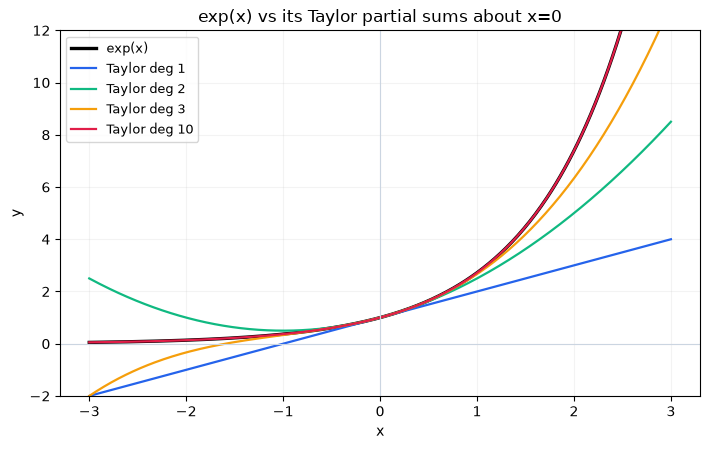

In [3]:
def taylor_exp(n, xs):
    coeffs = [1.0 / math.factorial(k) for k in range(n + 1)]
    return np.polyval(coeffs[::-1], xs)

xs = np.linspace(-3.0, 3.0, 400)
plt.figure(figsize=(7.2, 4.6))
plt.plot(xs, np.exp(xs), color="black", lw=2.4, label="exp(x)")
for n, color in zip([1, 2, 3, 10], ["#2563eb", "#10b981", "#f59e0b", "#e11d48"]):
    plt.plot(xs, taylor_exp(n, xs), lw=1.6, color=color, label=f"Taylor deg {n}")
plt.ylim(-2, 12)
plt.axhline(0, color="#cbd5e1", lw=0.8); plt.axvline(0, color="#cbd5e1", lw=0.8)
plt.title("exp(x) vs its Taylor partial sums about x=0")
plt.xlabel("x"); plt.ylabel("y"); plt.legend(loc="upper left", fontsize=9)
plt.grid(alpha=0.15); plt.tight_layout(); plt.show()

## 2. 테일러 계수와 반복 미분
$e^x=\sum A_n x^n$ 으로 두고, $n$번 미분한 뒤 $x=0$을 넣으면 $n!\,A_n$만 살아남으므로
$$A_n=\frac{f^{(n)}(0)}{n!}.$$
$f=e^x$이면 $f^{(n)}(0)=1$이라 $A_n=1/n!$. 직접 반복 미분으로 확인합니다.

In [4]:
f = sp.exp(x)
for n in range(6):
    An = sp.diff(f, x, n).subs(x, 0) / sp.factorial(n)
    print(f"n={n}:  f^({n})(0)={sp.diff(f, x, n).subs(x, 0)},  A_n = f^({n})(0)/{n}! = {An}")
print("=> e^x =", sp.series(sp.exp(x), x, 0, 6))

n=0:  f^(0)(0)=1,  A_n = f^(0)(0)/0! = 1
n=1:  f^(1)(0)=1,  A_n = f^(1)(0)/1! = 1
n=2:  f^(2)(0)=1,  A_n = f^(2)(0)/2! = 1/2
n=3:  f^(3)(0)=1,  A_n = f^(3)(0)/3! = 1/6
n=4:  f^(4)(0)=1,  A_n = f^(4)(0)/4! = 1/24
n=5:  f^(5)(0)=1,  A_n = f^(5)(0)/5! = 1/120
=> e^x = 1 + x + x**2/2 + x**3/6 + x**4/24 + x**5/120 + O(x**6)


## 3. 전개 중심 $a$와 국소 모델
중심 $a$ 근처에서는 $x-a$의 거듭제곱으로 전개합니다.
$$f(x)\approx f(a)+f'(a)(x-a)+\tfrac{f''(a)}{2}(x-a)^2+\cdots$$
강의의 예제: $\sin 31^\circ$를 $\sin 30^\circ=\tfrac12,\ \cos 30^\circ=\tfrac{\sqrt3}{2}$로 1차 근사합니다.

In [5]:
deg = sp.rad(1)                                       # 1 degree in radians
approx1 = sp.Rational(1, 2) + (sp.sqrt(3)/2) * deg     # f(a)+f'(a)(x-a), a=30 deg
print("sin31 (1st-order) =", float(approx1))
print("sin31 (exact)     =", float(sp.sin(sp.rad(31))))
print("abs error         =", abs(float(approx1) - float(sp.sin(sp.rad(31)))))

sin31 (1st-order) = 0.5151149947019518
sin31 (exact)     = 0.5150380749100543
abs error         = 7.691979189750064e-05


같은 중심 $a$에서 차수를 1·2·3으로 올리면(수평선 → 접선 → 포물선) 근처가 더 잘 맞습니다.
$f=\sin$, 중심 $a=30^\circ$ 에서의 1·2·3차 국소 모델을 겹쳐 그립니다.

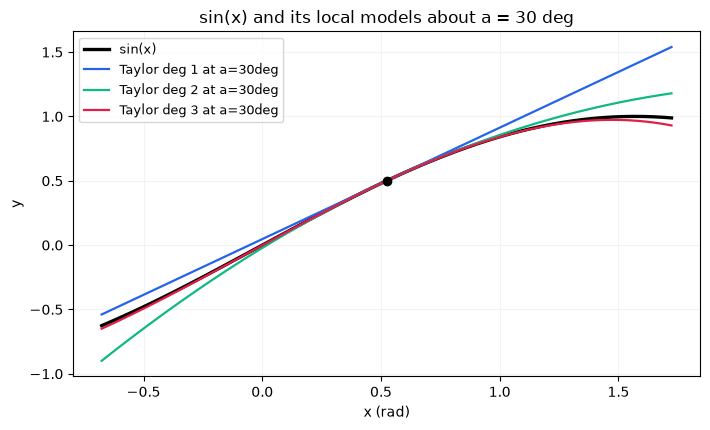

In [6]:
a0 = np.pi / 6
xs = np.linspace(a0 - 1.2, a0 + 1.2, 400)
plt.figure(figsize=(7.2, 4.4))
plt.plot(xs, np.sin(xs), color="black", lw=2.4, label="sin(x)")
s = sp.sin(x)
for n, color in zip([1, 2, 3], ["#2563eb", "#10b981", "#e11d48"]):
    poly = sum(sp.diff(s, x, k).subs(x, sp.pi/6) / sp.factorial(k) * (x - sp.pi/6)**k
               for k in range(n + 1))
    fn = sp.lambdify(x, poly, "numpy")
    plt.plot(xs, fn(xs), lw=1.6, color=color, label=f"Taylor deg {n} at a=30deg")
plt.scatter([a0], [np.sin(a0)], color="black", zorder=5)
plt.title("sin(x) and its local models about a = 30 deg")
plt.xlabel("x (rad)"); plt.ylabel("y"); plt.legend(fontsize=9)
plt.grid(alpha=0.15); plt.tight_layout(); plt.show()

## 4. "극한이 0" — $h^2/h$와 임의로 가까워진다는 말
분자 $h^2$도 분모 $h$도 $0$이 아니지만 몫 $h^2/h=h$는 $0$으로 갑니다.
핵심은 분자가 분모보다 **더 빨리** 작아진다는 것. 약분하지 않고 표로 확인합니다.

In [7]:
print(f"{'h':>10}{'h^2 (num)':>14}{'h (den)':>12}{'h^2/h':>12}")
for hv in [0.1, 0.01, 0.001, 1e-4, 1e-5]:
    print(f"{hv:>10}{hv**2:>14.1e}{hv:>12.0e}{(hv**2)/hv:>12.0e}")
print("symbolic limit h^2/h as h->0 :", sp.limit(h**2 / h, h, 0))

         h     h^2 (num)     h (den)       h^2/h
       0.1       1.0e-02       1e-01       1e-01
      0.01       1.0e-04       1e-02       1e-02
     0.001       1.0e-06       1e-03       1e-03
    0.0001       1.0e-08       1e-04       1e-04
     1e-05       1.0e-10       1e-05       1e-05
symbolic limit h^2/h as h->0 : 0


## 7. 미분가능성: "직선을 그을 수 있다"를 식으로
접선 두 항을 뺀 나머지 $f(a+h)-f(a)-h f'(a)$ 가 미분 가능한 점에서는 $h^2$ 꼴(2차 이상)이라,
$h$로 나눈 몫이 $0$으로 갑니다. 반면 $|x|$의 원점에서는 그렇지 않습니다.

In [8]:
def diff_quotient(expr, pt):
    f = sp.Lambda(x, expr)
    deriv = sp.diff(expr, x).subs(x, pt)
    num = f(pt + h) - f(pt) - h * deriv
    return sp.simplify(num), sp.limit(num / h, h, 0)

num_exp, lim_exp = diff_quotient(sp.exp(x), 0)         # smooth point
print("e^x at 0 : numerator f(a+h)-f(a)-h f'(a) ~", sp.series(num_exp, h, 0, 3))
print("          [num]/h  ->", lim_exp, " (= 0, so differentiable)")

# |x| at 0: use one-sided slope candidate 0; numerator is |h|, |h|/h has no limit
print("|x| at 0 : numerator = |h|,   |h|/h limit from + :",
      sp.limit(sp.Abs(h)/h, h, 0, '+'), " from - :", sp.limit(sp.Abs(h)/h, h, 0, '-'),
      " -> two-sided limit DNE (not differentiable)")

e^x at 0 : numerator f(a+h)-f(a)-h f'(a) ~ h**2/2 + O(h**3)
          [num]/h  -> 0  (= 0, so differentiable)
|x| at 0 : numerator = |h|,   |h|/h limit from + : 1  from - : -1  -> two-sided limit DNE (not differentiable)


접선을 뺀 오차가 $h$보다 빨리 작아지는 매끄러운 경우($e^x$)와,
원점에서 꺾여 그러지 못하는 경우($|x|$)를 비교해 그립니다. 매끄러운 점은
확대할수록 직선이 되고, 꺾인 점은 아무리 확대해도 꺾인 모양이 남습니다.

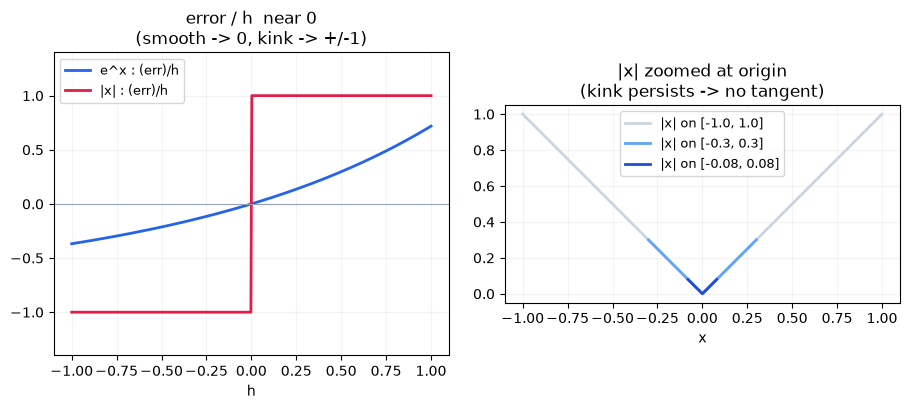

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(9.2, 4.2))
hs = np.linspace(-1.0, 1.0, 400)

# left: error/h for e^x (smooth) and |x| (kink), both with tangent slope at 0
err_exp = (np.exp(hs) - 1 - hs * 1.0)                 # e^x: f'(0)=1
err_abs = (np.abs(hs) - 0 - hs * 0.0)                 # |x|: best line slope 0
axes[0].plot(hs, err_exp / hs, color="#2563eb", lw=2, label="e^x : (err)/h")
axes[0].plot(hs, err_abs / hs, color="#e11d48", lw=2, label="|x| : (err)/h")
axes[0].axhline(0, color="#94a3b8", lw=0.8)
axes[0].set_title("error / h  near 0\n(smooth -> 0, kink -> +/-1)")
axes[0].set_xlabel("h"); axes[0].set_ylim(-1.4, 1.4)
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.15)

# right: zoom on |x| at origin - the kink never straightens
for w, color in zip([1.0, 0.3, 0.08], ["#cbd5e1", "#60a5fa", "#1d4ed8"]):
    t = np.linspace(-w, w, 200)
    axes[1].plot(t, np.abs(t), color=color, lw=2, label=f"|x| on [-{w}, {w}]")
axes[1].set_title("|x| zoomed at origin\n(kink persists -> no tangent)")
axes[1].set_xlabel("x"); axes[1].set_aspect("equal")
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.15)
fig.tight_layout(); plt.show()